# Prediksi Jumlah Pernikahan Kabupaten/Kota di Provinsi Sulawesi Tengah Berdasarkan Tingkat Pengangguran dan Jumlah Penduduk Tahun 2018–2025

Tugas Statistika - Machine Learning Regression

# Data Collecting

Dataset yang digunakan untuk memprediksi jumlah pernikahan kabupaten/kota di Provinsi Sulawesi Tengah berdasarkan tingkat pengangguran dan jumlah penduduk tahun 2018–2025.

Dataset berisi 5 kolom:
- **Kabupaten_Kota** : nama kabupaten/kota di Provinsi Sulawesi Tengah
- **Tahun** : tahun data (2018–2025)
- **Jumlah_Penduduk_X1** : jumlah penduduk (dalam ribuan jiwa)
- **Tingkat_Pengangguran_X2** : tingkat pengangguran terbuka (%)
- **Jumlah_Pernikahan_Y** : jumlah peristiwa pernikahan (target/variabel yang diprediksi)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "dataset.csv"
df = pd.read_csv(file_path)

# Exploratory Data Analysis

In [ ]:
print(df.head())

  Kabupaten_Kota  Tahun  Jumlah_Penduduk_X1  Tingkat_Pengangguran_X2  \
0        Banggai   2018              371.30                     3.00   
1        Banggai   2019              376.80                     2.18   
2        Banggai   2020              362.30                     2.42   
3        Banggai   2021              366.22                     3.57   
4        Banggai   2022              370.97                     3.09   

   Jumlah_Pernikahan_Y  
0                 2320  
1                 2182  
2                 2172  
3                 2112  
4                 1926  


In [ ]:
df.describe()

,Tahun,Jumlah_Penduduk_X1,Tingkat_Pengangguran_X2,Jumlah_Pernikahan_Y
count,104.000000,104.000000,104.000000,104.000000
mean,2021.500000,235.603462,3.155000,1332.144231
std,2.302384,114.315513,1.204364,780.226149
min,2018.000000,70.400000,1.480000,166.000000
25%,2019.750000,141.375000,2.470000,620.500000
50%,2021.500000,232.555000,2.975000,1156.500000
75%,2023.250000,308.975000,3.352500,1843.500000
max,2025.000000,490.900000,8.380000,3155.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Kabupaten_Kota           104 non-null    object 
 1   Tahun                    104 non-null    int64  
 2   Jumlah_Penduduk_X1       104 non-null    float64
 3   Tingkat_Pengangguran_X2  104 non-null    float64
 4   Jumlah_Pernikahan_Y      104 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 4.2+ KB


In [ ]:
df.shape

(104, 5)

In [ ]:
df.isnull().sum()

,0
Kabupaten_Kota,0
Tahun,0
Jumlah_Penduduk_X1,0
Tingkat_Pengangguran_X2,0
Jumlah_Pernikahan_Y,0


In [ ]:
df.duplicated().sum()

np.int64(0)


==== Deteksi Outlier dengan IQR pada kolom Jumlah_Pernikahan_Y ====
Batas Bawah : -1214.0
Batas Atas  : 3678.0
Jumlah Jumlah_Pernikahan_Y Outlier : 0 baris dari total 104 baris data


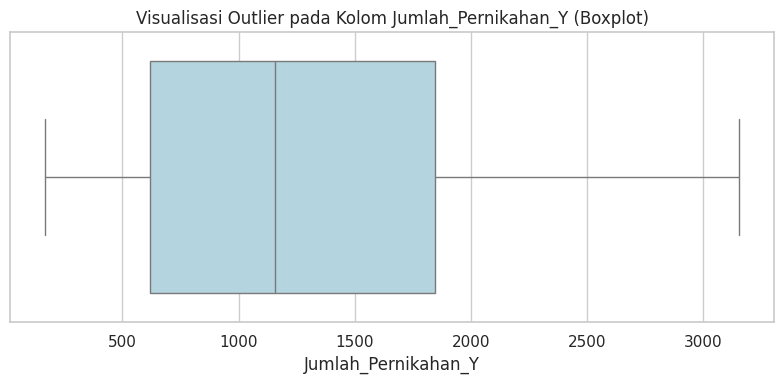

In [ ]:
kolom_target = 'Jumlah_Pernikahan_Y'

print(f"\n==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightblue')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)')
plt.xlabel(kolom_target)
plt.tight_layout()
plt.show()

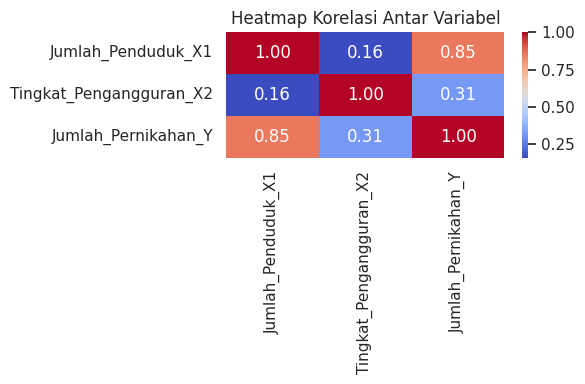

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[["Jumlah_Penduduk_X1", "Tingkat_Pengangguran_X2", "Jumlah_Pernikahan_Y"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
print(f"Jumlah data sebelum dihapus: {len(df)}")

df = df[(df['Jumlah_Pernikahan_Y'] >= lower_bound) & (df['Jumlah_Pernikahan_Y'] <= upper_bound)]

print(f"Jumlah data setelah dihapus: {len(df)}")

Jumlah data sebelum dihapus: 104
Jumlah data setelah dihapus: 104


In [ ]:
df = df[["Kabupaten_Kota", "Tahun", "Jumlah_Penduduk_X1", "Tingkat_Pengangguran_X2", "Jumlah_Pernikahan_Y"]]

df["Kode_Wilayah"] = df["Kabupaten_Kota"].astype("category").cat.codes

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Kabupaten_Kota           104 non-null    object 
 1   Tahun                    104 non-null    int64  
 2   Jumlah_Penduduk_X1       104 non-null    float64
 3   Tingkat_Pengangguran_X2  104 non-null    float64
 4   Jumlah_Pernikahan_Y      104 non-null    int64  
 5   Kode_Wilayah             104 non-null    int8   
dtypes: float64(2), int64(2), int8(1), object(1)
memory usage: 4.3+ KB
None


In [ ]:
X = df[["Kode_Wilayah", "Tahun", "Jumlah_Penduduk_X1", "Tingkat_Pengangguran_X2"]]
y = df["Jumlah_Pernikahan_Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Visualisasi

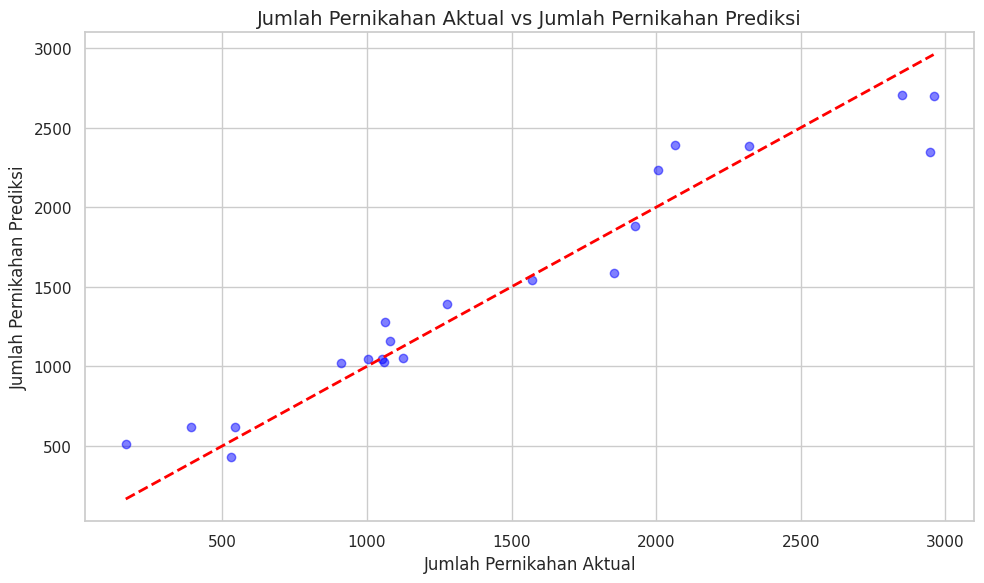

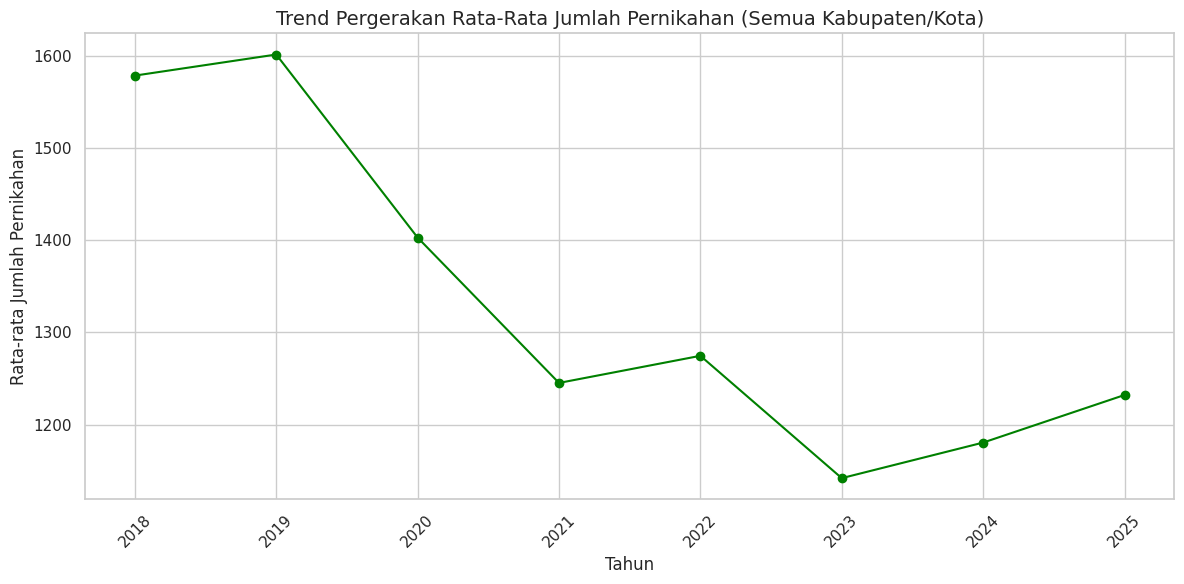

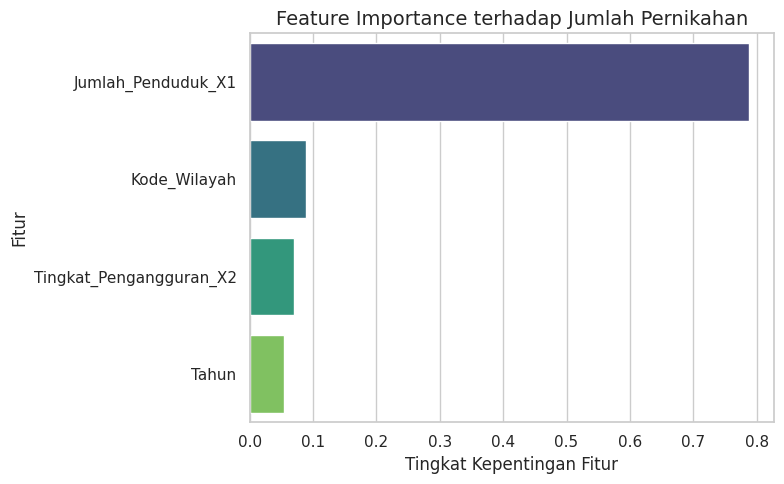

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', lw=2, color='red')

plt.title('Jumlah Pernikahan Aktual vs Jumlah Pernikahan Prediksi', fontsize=14)
plt.xlabel('Jumlah Pernikahan Aktual', fontsize=12)
plt.ylabel('Jumlah Pernikahan Prediksi', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

trend_data = df.groupby('Tahun')['Jumlah_Pernikahan_Y'].mean().reset_index()

plt.plot(trend_data['Tahun'], trend_data['Jumlah_Pernikahan_Y'], color='green', linewidth=1.5, marker='o')
plt.title('Trend Pergerakan Rata-Rata Jumlah Pernikahan (Semua Kabupaten/Kota)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata Jumlah Pernikahan', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance terhadap Jumlah Pernikahan', fontsize=14)
plt.xlabel('Tingkat Kepentingan Fitur', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.tight_layout()
plt.show()

# Evaluasi Model

| Metrik | Digunakan ketika                                          |
| ------ | --------------------------------------------------------- |
| MAE    | Jika Ingin mengetahui rata-rata kesalahan secara langsung |
| MSE    | Jika Error besar harus dihukum lebih berat                |
| RMSE   | Jika Ingin ukuran error yang mudah diinterpretasikan      |
| R²     | Jika Ingin melihat seberapa baik model menjelaskan data   |

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== EVALUASI MODEL ===")
print("r2   :", round(r2, 2))
print("MSE  :", round(mse, 2))
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))

hasil_uji = pd.DataFrame({
    "Jumlah Pernikahan Asli": y_test.values[:10],
    "Jumlah Pernikahan Prediksi": y_pred[:10]
})

print("\n=== CONTOH HASIL PREDIKSI ===")
print(hasil_uji)


=== EVALUASI MODEL ===
r2   : 0.93
MSE  : 45627.0
MAE  : 161.31
RMSE : 213.6

=== CONTOH HASIL PREDIKSI ===
   Jumlah Pernikahan Asli  Jumlah Pernikahan Prediksi
0                    1002                     1046.35
1                    2959                     2696.22
2                    2849                     2702.31
3                    1053                     1047.21
4                    2066                     2388.94
5                     909                     1020.91
6                    1063                     1275.93
7                    2005                     2230.73
8                     392                      620.86
9                    2320                     2386.66


# Deployment

In [ ]:
mapping_wilayah = dict(enumerate(df["Kabupaten_Kota"].astype("category").cat.categories))

print("\n=== DAFTAR KODE KABUPATEN/KOTA ===")
for kode, wilayah in mapping_wilayah.items():
    print(f"{kode} : {wilayah}")


=== DAFTAR KODE KABUPATEN/KOTA ===
0 : Banggai
1 : Banggai Kepulauan
2 : Banggai Laut
3 : Buol
4 : Donggala
5 : Kota Palu
6 : Morowali
7 : Morowali Utara
8 : Parigi Moutong
9 : Poso
10 : Sigi
11 : Tojo Una-Una
12 : Toli-Toli


In [ ]:
kode_wilayah = 4
tahun = 2026
jumlah_penduduk = 400.0
tingkat_pengangguran = 5.5

data_baru = pd.DataFrame([{
    "Kode_Wilayah": kode_wilayah,
    "Tahun": tahun,
    "Jumlah_Penduduk_X1": jumlah_penduduk,
    "Tingkat_Pengangguran_X2": tingkat_pengangguran
}])

prediksi_baru = model.predict(data_baru)[0]

print("\n=== HASIL PREDIKSI BARU ===")
print("Kabupaten/Kota          :", mapping_wilayah.get(kode_wilayah, "Tidak diketahui"))
print("Tahun                   :", tahun)
print("Prediksi Jumlah Nikah   :", round(prediksi_baru))
print("Provinsi                : Sulawesi Tengah")


=== HASIL PREDIKSI BARU ===
Kabupaten/Kota          : Donggala
Tahun                   : 2026
Prediksi Jumlah Nikah   : 2114
Provinsi                : Sulawesi Tengah


# Kesimpulan

Berdasarkan hasil pemodelan Random Forest Regressor terhadap data jumlah pernikahan kabupaten/kota di Provinsi Sulawesi Tengah tahun 2018–2025, dapat disimpulkan beberapa hal:

1. Model memberikan gambaran hubungan antara **jumlah penduduk**, **tingkat pengangguran**, dan **wilayah** terhadap **jumlah pernikahan** di setiap kabupaten/kota.
2. Nilai R², MAE, MSE, dan RMSE pada bagian evaluasi model menunjukkan seberapa baik model dalam memprediksi jumlah pernikahan dibandingkan data aktualnya.
3. Visualisasi *feature importance* menunjukkan fitur mana (jumlah penduduk, tingkat pengangguran, atau wilayah) yang paling berpengaruh terhadap jumlah pernikahan.
4. Tren rata-rata jumlah pernikahan tahun 2018–2025 dapat digunakan sebagai gambaran awal pola pernikahan di Provinsi Sulawesi Tengah, sebelum dianalisis lebih lanjut dengan model.
